In [1]:
# Cell 1: Data Setup and Fast Retraining
import pandas as pd
import numpy as np
import lightgbm as lgb
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
import re
import warnings
warnings.filterwarnings('ignore')

print("--- Step 1: Data Preparation ---")
df = pd.read_csv('application_train_fully_preprocessed.csv')
df = df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("--- Step 2: Training Models for Comparison ---")
# 1. Baseline Model
model_base = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, is_unbalance=True, random_state=42, n_jobs=-1)
model_base.fit(X_train, y_train)
print("Baseline Trained")

# 2. Method A: 1:1 Undersampling
rus_11 = RandomUnderSampler(random_state=42)
X_train_11, y_train_11 = rus_11.fit_resample(X_train, y_train)
model_11 = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1)
model_11.fit(X_train_11, y_train_11)
print("1:1 Undersampling Trained")

# 3. Method B: 1:3 Downsampling
rus_13 = RandomUnderSampler(sampling_strategy=0.33, random_state=42)
X_train_13, y_train_13 = rus_13.fit_resample(X_train, y_train)
model_13 = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1)
model_13.fit(X_train_13, y_train_13)
print("1:3 Downsampling Trained")

--- Step 1: Data Preparation ---
--- Step 2: Training Models for Comparison ---
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020711 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3184
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 153
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Baseline Trained
[LightGBM] [Info] Number of positive: 19860, number of negative: 19860
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009298 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3125
[LightGBM] [Info] Number of data points in the train set: 39720, number of 

In [3]:
# Cell 2: The Threshold Tuning Function
from sklearn.metrics import precision_recall_curve

def optimize_threshold(model, X_test, y_test, model_name):
    # 1. Get Probabilities
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 2. Calculate Precision, Recall, Thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
    
    # 3. Safely calculate F1-Score to avoid Division by Zero
    f1_scores = np.zeros_like(precisions)
    mask = (precisions + recalls) > 0 
    f1_scores[mask] = 2 * (precisions[mask] * recalls[mask]) / (precisions[mask] + recalls[mask])
    
    # 4. Find the Peak
    optimal_idx = np.argmax(f1_scores)
    opt_thresh = thresholds[optimal_idx]
    opt_f1 = f1_scores[optimal_idx]
    opt_prec = precisions[optimal_idx]
    opt_rec = recalls[optimal_idx]
    
    # Calculate Default F1 (at 0.50) for comparison
    default_idx = np.abs(thresholds - 0.5).argmin()
    default_f1 = f1_scores[default_idx]
    
    return {
        "Model Name": model_name,
        "Optimal Threshold": round(opt_thresh, 4),
        "Default F1 (0.50)": round(default_f1, 4),
        "Optimal F1": round(opt_f1, 4),
        "New Precision": round(opt_prec, 4),
        "New Recall": round(opt_rec, 4)
    }

print(" Optimization Function Ready!")

 Optimization Function Ready!



 --- THE TRUE POTENTIAL OF ALL MODELS --- 

                  Model Name  Optimal Threshold  Default F1 (0.50)  Optimal F1  New Precision  New Recall
Baseline (is_unbalance=True)             0.5796             0.2445      0.2619         0.1842      0.4532
 Method A (1:1 Undersampled)             0.6375             0.2328      0.2561         0.1926      0.3821
  Method B (1:3 Downsampled)             0.3373             0.1913      0.2604         0.1858      0.4354


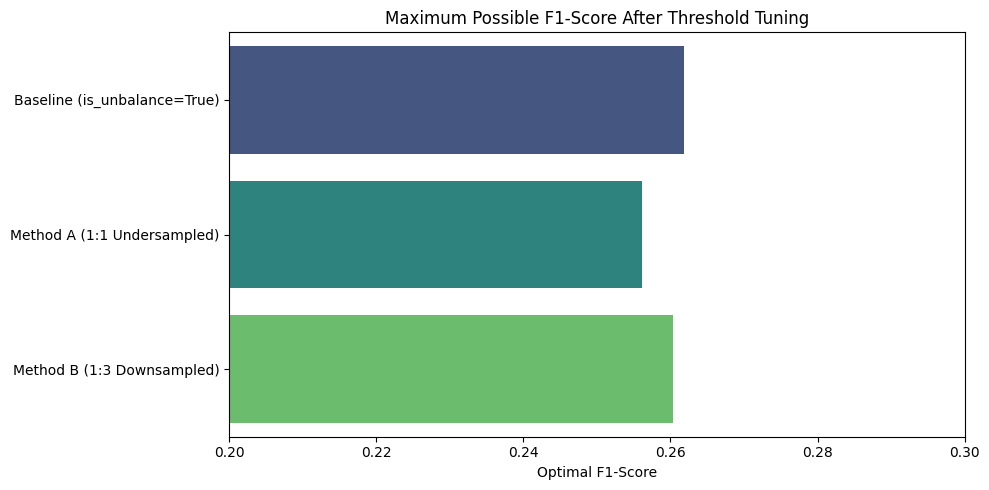

In [5]:
# Cell 3: Execute Optimization and Compare
results = []

# Run the optimizer for all three models
results.append(optimize_threshold(model_base, X_test, y_test, "Baseline (is_unbalance=True)"))
results.append(optimize_threshold(model_11, X_test, y_test, "Method A (1:1 Undersampled)"))
results.append(optimize_threshold(model_13, X_test, y_test, "Method B (1:3 Downsampled)"))

# Convert to a DataFrame for clean viewing
comparison_df = pd.DataFrame(results)

print("\n --- THE TRUE POTENTIAL OF ALL MODELS --- \n")
print(comparison_df.to_string(index=False))

# Optional: Plotting a quick visual comparison of Optimal F1 Scores
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(x='Optimal F1', y='Model Name', data=comparison_df, palette='viridis')
plt.title('Maximum Possible F1-Score After Threshold Tuning')
plt.xlabel('Optimal F1-Score')
plt.ylabel('')
plt.xlim(0.20, 0.30) # Zoom in to see the difference
plt.tight_layout()
plt.show()

Baseline still performance the best after Optimal 